# Algorithm Visualizer

Visualizer of the fitting algorithm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from specparam import SpectralModel
from specparam.data.periodic import sort_peaks
from specparam.plts.spectra import plot_spectra
from specparam.plts.annotate import plot_individual_peak_search, _recompute_flatspec
from specparam.plts.settings import PLT_COLORS
from specparam.sim.gen import gen_aperiodic
from specparam.utils.download import load_example_data
from specparam.measures.estimates import estimate_fwhm
from specparam.measures.params import compute_gauss_std

## Setup: Data & Model Fit

In [2]:
# Load example data files needed for this example
freqs = load_example_data('freqs_2.npy', folder='data')
spectrum = load_example_data('spectrum_2.npy', folder='data')

In [3]:
# Initialize a model object
fm = SpectralModel(peak_width_limits=[1, 8], max_n_peaks=6, min_peak_height=0.15)

In [4]:
# Add data to the object
fm.add_data(freqs, spectrum, [3, 40])

In [5]:
# Fit the power spectrum model
fm.fit(freqs, spectrum, [3, 40])

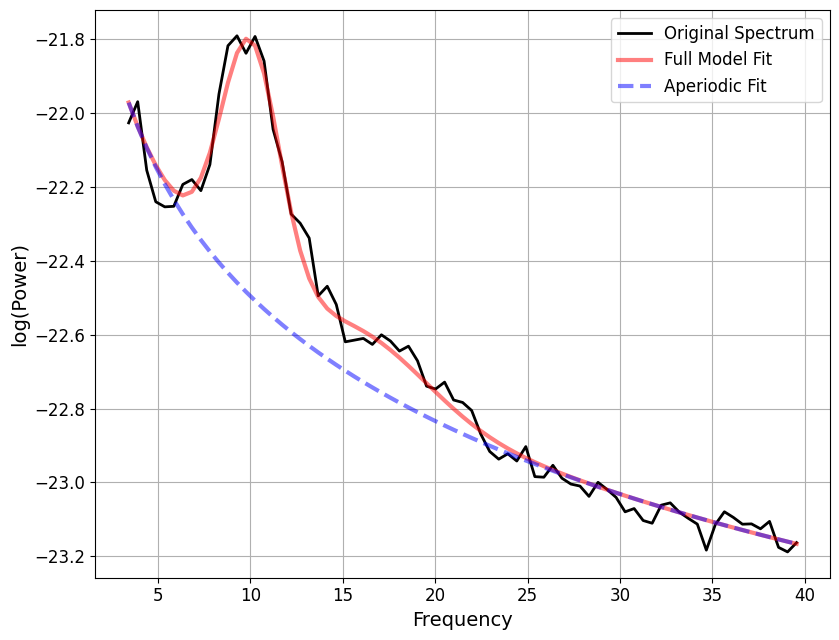

In [6]:
fm.plot()

## Setup: Visualizer Layout

In [7]:
TEXT_KWARGS = {                          
    'horizontalalignment' : 'center',
    'verticalalignment' : 'center',
}

In [8]:
def make_axes():
    
    fig = plt.figure(figsize=(10, 7), constrained_layout=True)
    gs = fig.add_gridspec(6, 4)
    
    ticks = {'xticks' : [], 'yticks' : []}

    axes = {}
    axes['main'] = fig.add_subplot(gs[1:-1, 0:2])
    axes['main'].set(**ticks)
    
    axes['text_top'] = fig.add_subplot(gs[0, 0:2])
    axes['text_bot'] = fig.add_subplot(gs[5, 0:2])
    axes['text_top'].axis('off')
    axes['text_bot'].axis('off')
    
    axes['text_top'].text(0.5, 0.6, 'Spectral Parameterization', 
                          **TEXT_KWARGS, fontsize=18)

    axes['data_fu'] = fig.add_subplot(gs[0:2, 2])
    axes['data_fu'].set(title='Data - Full', **ticks)
    axes['data_ap'] = fig.add_subplot(gs[2:4, 2])
    axes['data_ap'].set(title='Data - AP', **ticks)
    axes['data_pe'] = fig.add_subplot(gs[4:, 2])
    axes['data_pe'].set(title='Data - PE', **ticks)
    
    axes['model_fu'] = fig.add_subplot(gs[0:2, 3])
    axes['model_fu'].set(title='Model - Full', **ticks)
    axes['model_ap'] = fig.add_subplot(gs[2:4, 3])
    axes['model_ap'].set(title='Model - AP', **ticks)
    axes['model_pe'] = fig.add_subplot(gs[4:6, 3])
    axes['model_pe'].set(title='Model - PE', **ticks)
    
    return fig, axes

In [9]:
## Plot settings

labels = {
    'xlabel' : None,
    'ylabel' : None,
}

face_color = 'yellow'
face_color = '#fdfd96'

## Visualizer - Step by Step

### Step 0

In [10]:
def add_param_text(tax, ap=None, pe=None, gof=None, highlight=None):
    
    tax.text(0.5, 0.95, 'Parameters', **TEXT_KWARGS, fontsize=12)
    
    if ap is None:
        ap_text = 'Aperiodic - null'
    else:
        ap_text = 'Aperiodic  -  OFF: {:1.2f}; EXP: {:1.2f}'.format(ap[0], ap[1])
    tax.text(0.5, 0.55, ap_text, **TEXT_KWARGS, fontsize=10,
             color='red' if highlight == 'ap' else 'black')
    
    if pe is None:
        pe_text = 'Peak - null' 
    else:
        if pe.ndim == 1:
            pe_text = 'Peak - CF: {:1.2f}, PW: {:1.2f}, BW: {:1.2f}'.format(pe[0], pe[1], pe[2])
        elif pe.ndim == 2:
            pe_text = 'Peak - CF: [{:1.2f}, {:1.2f}] PW: [{:1.2f}, {:1.2f}]  BW: [{:1.2f}, {:1.2f}]'.format(\
                *pe[:, 0], *pe[:, 1], *pe[:, 2])
    tax.text(0.5, 0.30, pe_text, **TEXT_KWARGS, fontsize=10,
             color='red' if highlight == 'pe' else 'black')
    
    if gof is None:
        gof_text = 'GoF - null'
    else: 
        gof_text = 'GoF - Err: {:1.2f}, R^2: {:1.2f}'.format(gof['error_mae'], gof['gof_rsquared'])
    tax.text(0.5, 0.05, gof_text, **TEXT_KWARGS, fontsize=10,
             color='red' if highlight == 'gof' else 'black')

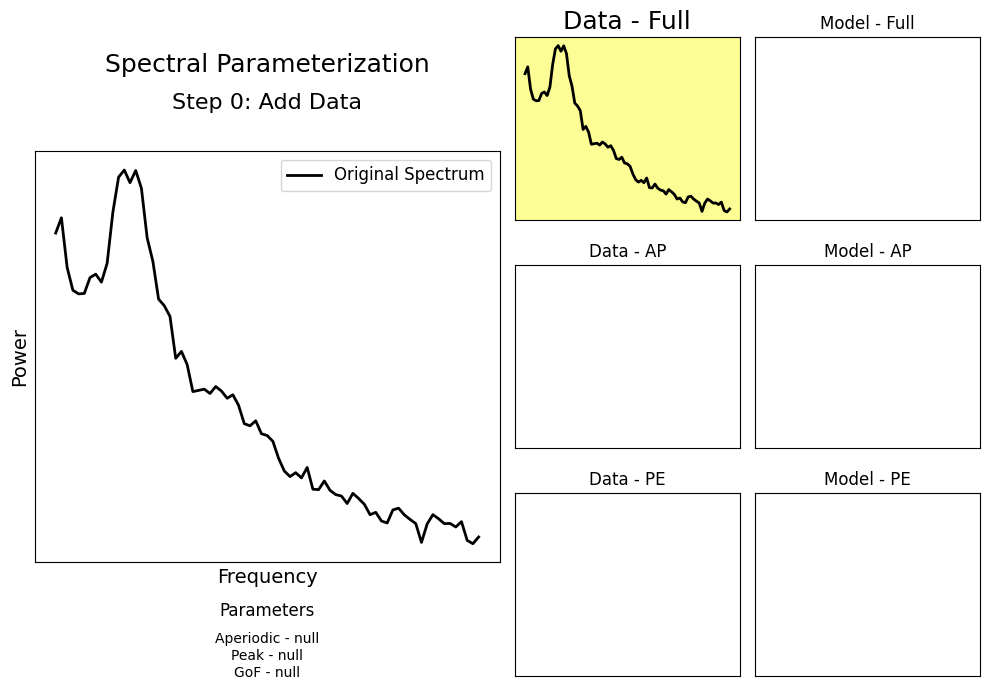

In [11]:
fig, axes = make_axes()

plot_spectra(fm.data.freqs, fm.data.power_spectrum, ax=axes['main'],
             color=PLT_COLORS['data'], label='Original Spectrum')

plot_spectra(fm.data.freqs, fm.data.power_spectrum, ax=axes['data_fu'],
             color=PLT_COLORS['data'], **labels)
axes['data_fu'].set_facecolor(face_color)

axes['text_top'].text(0.5, 0.05, 'Step 0: Add Data', **TEXT_KWARGS, fontsize=16)
add_param_text(axes['text_bot'])

### Step 1

In [12]:
init_ap_params = fm.algorithm._robust_ap_fit(fm.data.freqs, fm.data.power_spectrum)
init_ap_fit = gen_aperiodic(fm.data.freqs, 'fixed', init_ap_params)

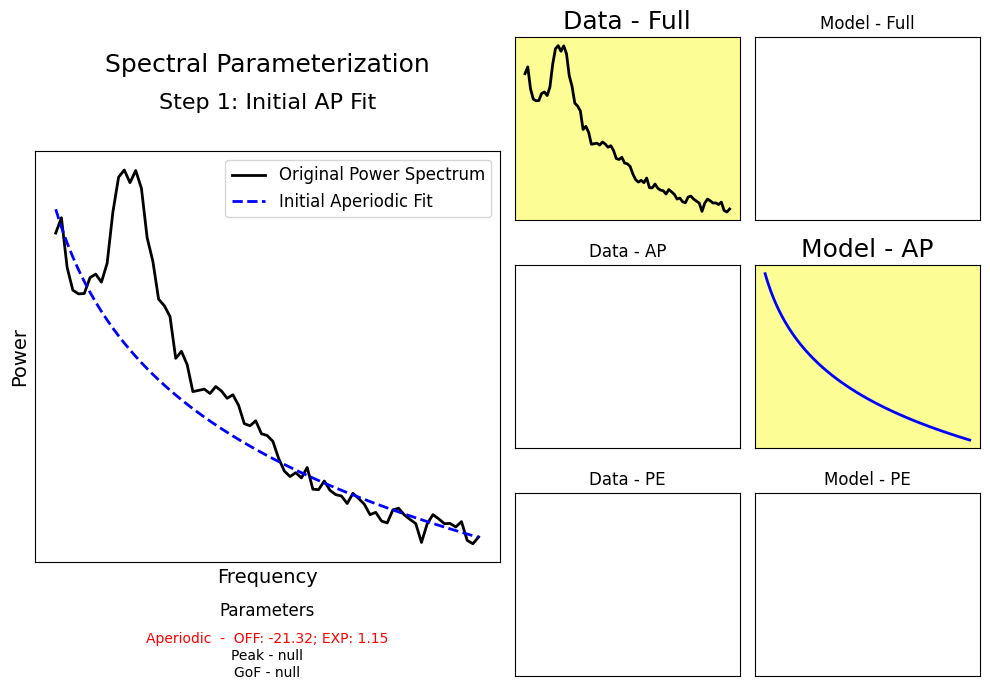

In [13]:
fig, axes = make_axes()
plot_spectra(fm.data.freqs, fm.data.power_spectrum, ax=axes['main'], 
             color=PLT_COLORS['data'], label='Original Power Spectrum')
plot_spectra(fm.data.freqs, init_ap_fit, ax=axes['main'],
             color=PLT_COLORS['aperiodic'], linestyle='dashed', label='Initial Aperiodic Fit')

plot_spectra(fm.data.freqs, fm.data.power_spectrum, ax=axes['data_fu'], color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, init_ap_fit, ax=axes['model_ap'], color=PLT_COLORS['aperiodic'], **labels)
axes['data_fu'].set_facecolor(face_color)
axes['model_ap'].set_facecolor(face_color)

axes['text_top'].text(0.5, 0.05, 'Step 1: Initial AP Fit', **TEXT_KWARGS, fontsize=16)
add_param_text(axes['text_bot'], ap=init_ap_params, highlight='ap')

### Step 2

In [14]:
init_flat_spec = fm.data.power_spectrum - init_ap_fit

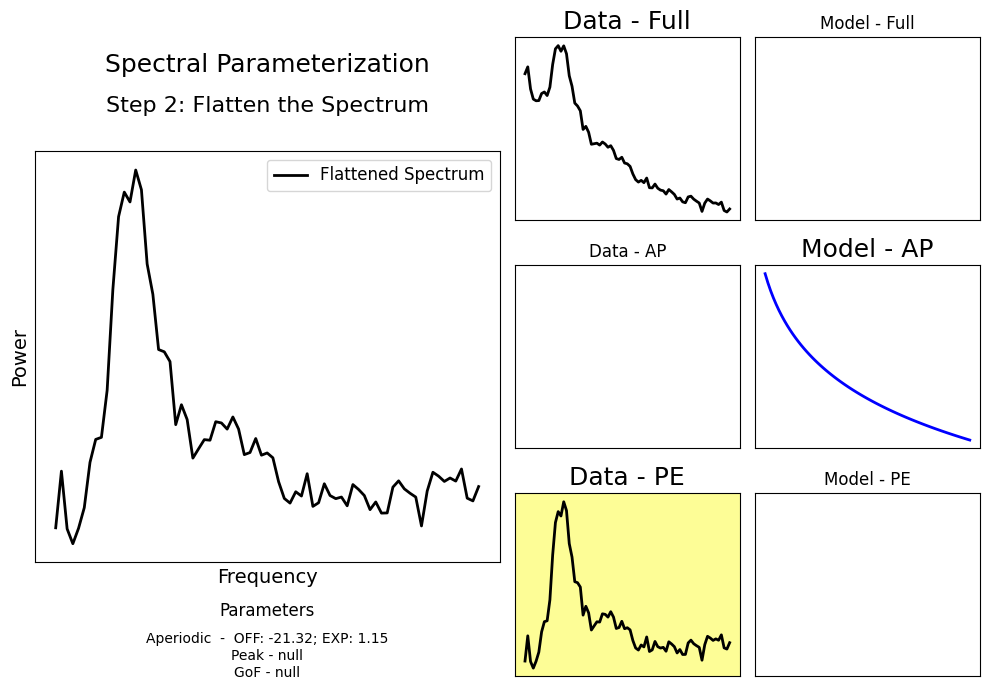

In [15]:
fig, axes = make_axes()

plot_spectra(fm.data.freqs, init_flat_spec, ax=axes['main'],
             color=PLT_COLORS['data'], label='Flattened Spectrum')

plot_spectra(fm.data.freqs, fm.data.power_spectrum, ax=axes['data_fu'], color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, init_ap_fit, ax=axes['model_ap'], color=PLT_COLORS['aperiodic'], **labels)
plot_spectra(fm.data.freqs, init_flat_spec, ax=axes['data_pe'], color=PLT_COLORS['data'], **labels)
axes['data_pe'].set_facecolor(face_color)

axes['text_top'].text(0.5, 0.0, 'Step 2: Flatten the Spectrum', **TEXT_KWARGS, fontsize=16)
add_param_text(axes['text_bot'], ap=init_ap_params)

### Step 3 (multiple iterations)

In [16]:
# Get recomputed flatspec, to set plot y-range
flatspec = _recompute_flatspec(fm)
ylim = [min(flatspec) - 0.1 * np.abs(min(flatspec)),
        max(flatspec) + 0.1 * max(flatspec)]

# Get Gaussian parameters to use for plotting 
gauss_params = sort_peaks(fm.results.params.gaussian, 'PW', 'dec')

In [17]:
# Recompute guess parameters for first peak
guess_params = np.array([
    fm.data.freqs[np.argmax(flatspec)], 
    flatspec[np.argmax(flatspec)],
    compute_gauss_std(estimate_fwhm(flatspec, np.argmax(flatspec), fm.data.freq_res)),
])

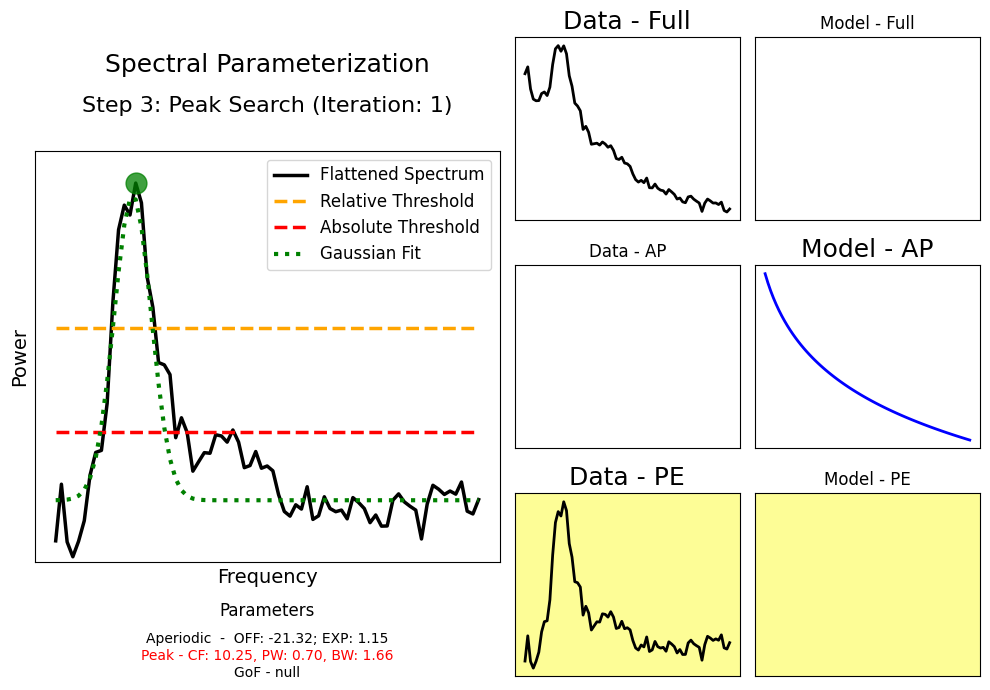

In [18]:
fig, axes = make_axes()

plot_individual_peak_search(fm, 0, title=None, ylim=ylim, restyle=False, ax=axes['main'])

plot_spectra(fm.data.freqs, fm.data.power_spectrum, ax=axes['data_fu'], color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, init_ap_fit, ax=axes['model_ap'], color=PLT_COLORS['aperiodic'], **labels)
plot_spectra(fm.data.freqs, init_flat_spec, ax=axes['data_pe'], color=PLT_COLORS['data'], **labels)
axes['data_pe'].set_facecolor(face_color)
axes['model_pe'].set_facecolor(face_color)

axes['text_top'].text(0.5, 0.0, 'Step 3: Peak Search (Iteration: 1)', **TEXT_KWARGS, fontsize=16);
add_param_text(axes['text_bot'], ap=init_ap_params, pe=guess_params, highlight='pe')

In [19]:
# Recompute guess parameters for second peak
flatspec2 = _recompute_flatspec(fm, 1)
guess_params2 = np.array([
    fm.data.freqs[np.argmax(flatspec2)], 
    flatspec[np.argmax(flatspec2)],
    compute_gauss_std(estimate_fwhm(flatspec2, np.argmax(flatspec2), fm.data.freq_res)),
])

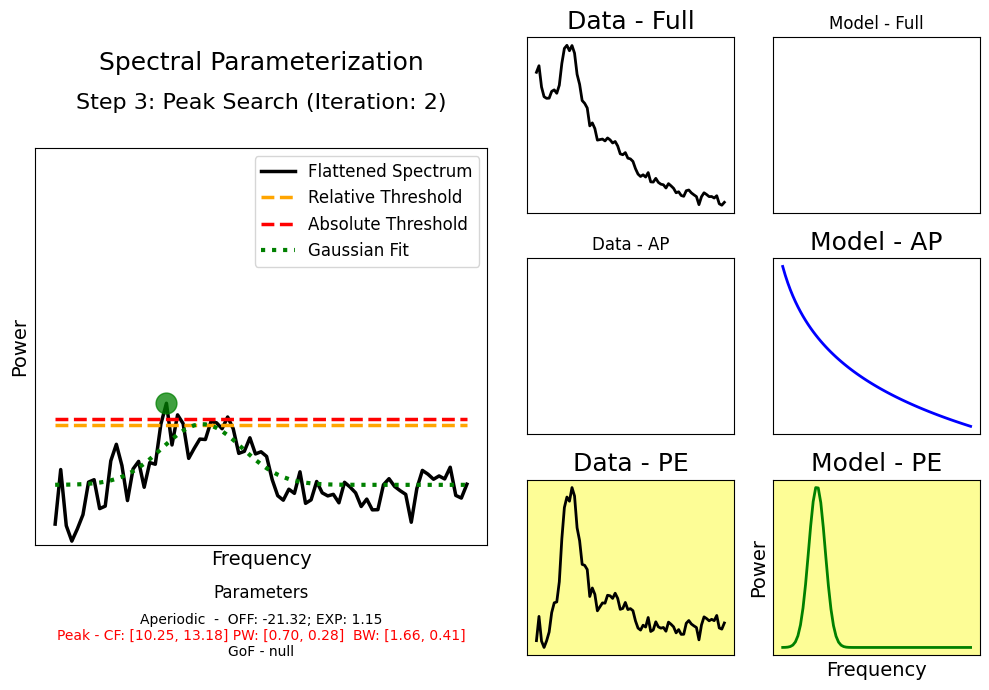

In [20]:
fig, axes = make_axes()

plot_individual_peak_search(fm, 1, title=None, ylim=ylim, restyle=False, ax=axes['main'])

plot_spectra(fm.data.freqs, fm.data.power_spectrum, ax=axes['data_fu'], color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, init_ap_fit, ax=axes['model_ap'], color=PLT_COLORS['aperiodic'], **labels)
plot_spectra(fm.data.freqs, init_flat_spec, ax=axes['data_pe'], color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, fm.modes.periodic.func(fm.data.freqs, *gauss_params[0, :]), 
             ax=axes['model_pe'], color=PLT_COLORS['periodic'])

axes['data_pe'].set_facecolor(face_color)
axes['model_pe'].set_facecolor(face_color)

axes['text_top'].text(0.5, 0.0, 'Step 3: Peak Search (Iteration: 2)', **TEXT_KWARGS, fontsize=16)
add_param_text(axes['text_bot'], ap=init_ap_params,
               pe=np.array([guess_params, guess_params2]), highlight='pe')

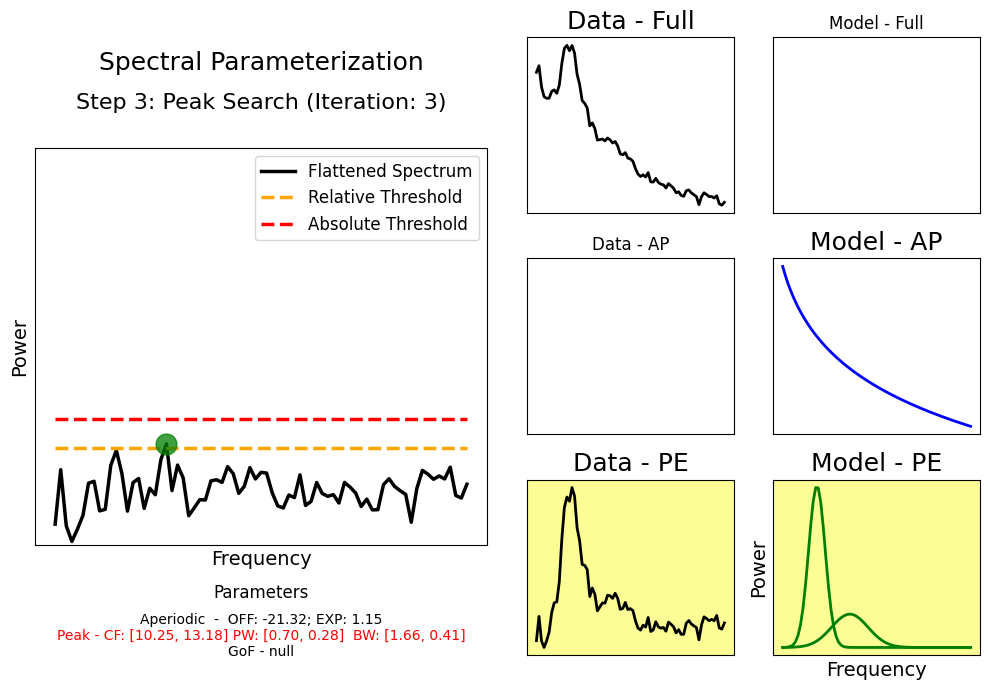

In [21]:
fig, axes = make_axes()

plot_individual_peak_search(fm, 2, title=None, ylim=ylim, restyle=False, ax=axes['main'])

plot_spectra(fm.data.freqs, fm.data.power_spectrum, ax=axes['data_fu'], color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, init_ap_fit, ax=axes['model_ap'], color=PLT_COLORS['aperiodic'], **labels)
plot_spectra(fm.data.freqs, init_flat_spec, ax=axes['data_pe'], color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, fm.modes.periodic.func(fm.data.freqs, *gauss_params[0, :]), 
             ax=axes['model_pe'], color=PLT_COLORS['periodic'])
plot_spectra(fm.data.freqs, fm.modes.periodic.func(fm.data.freqs, *gauss_params[1, :]), 
             ax=axes['model_pe'], color=PLT_COLORS['periodic'])

axes['data_pe'].set_facecolor(face_color)
axes['model_pe'].set_facecolor(face_color)

axes['text_top'].text(0.5, 0.0, 'Step 3: Peak Search (Iteration: 3)', **TEXT_KWARGS, fontsize=16)
add_param_text(axes['text_bot'], ap=init_ap_params,
               pe=np.array([guess_params, guess_params2]), highlight='pe')

### Step 4

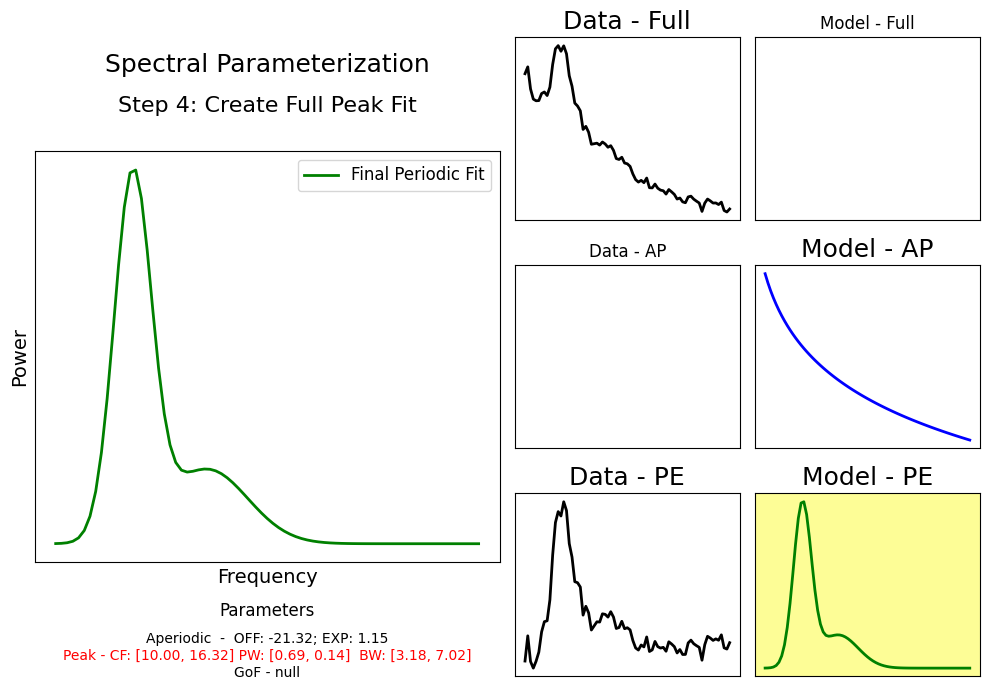

In [22]:
fig, axes = make_axes()

plot_spectra(fm.data.freqs, fm.results.model.get_component('peak'), 
             ax=axes['main'], color=PLT_COLORS['periodic'], label='Final Periodic Fit')

plot_spectra(fm.data.freqs, fm.data.power_spectrum, ax=axes['data_fu'], color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, init_ap_fit, ax=axes['model_ap'], color=PLT_COLORS['aperiodic'], **labels)
plot_spectra(fm.data.freqs, init_flat_spec, ax=axes['data_pe'], color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, fm.results.model.get_component('peak'), ax=axes['model_pe'], color=PLT_COLORS['periodic'], **labels)
axes['model_pe'].set_facecolor(face_color)

axes['text_top'].text(0.5, 0.0, 'Step 4: Create Full Peak Fit', **TEXT_KWARGS, fontsize=16)
add_param_text(axes['text_bot'], ap=init_ap_params,
               pe=fm.results.get_params('peak'), highlight='pe')

### Step 5

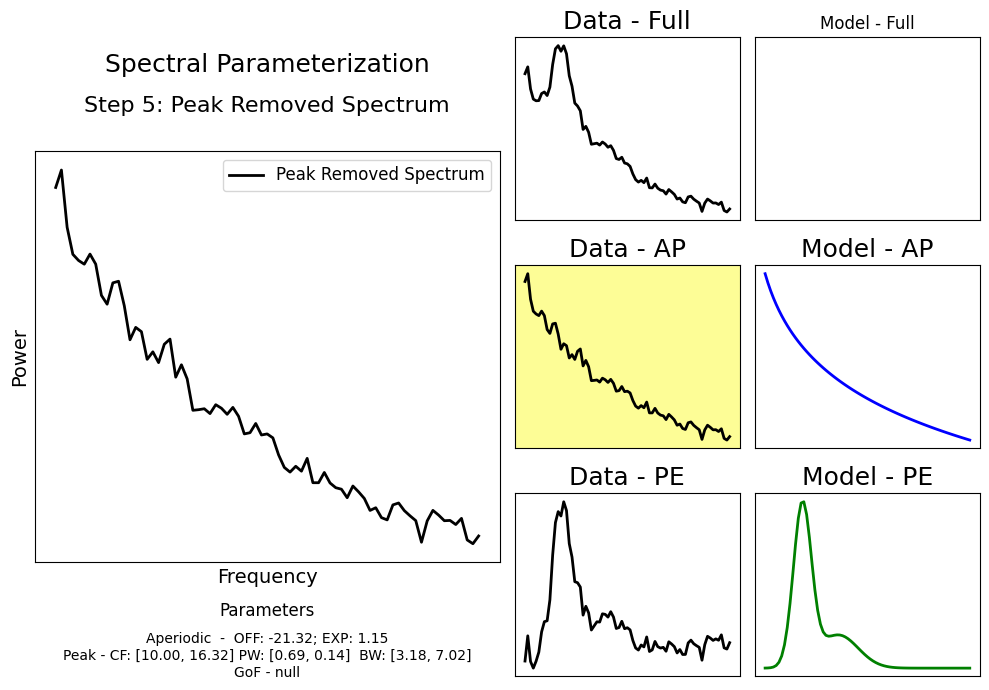

In [23]:
fig, axes = make_axes()

plot_spectra(fm.data.freqs, fm.get_data('aperiodic'), 
             ax=axes['main'], color=PLT_COLORS['data'], label='Peak Removed Spectrum')

plot_spectra(fm.data.freqs, fm.data.power_spectrum, ax=axes['data_fu'], color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, init_ap_fit, ax=axes['model_ap'], color=PLT_COLORS['aperiodic'], **labels)
plot_spectra(fm.data.freqs, init_flat_spec, ax=axes['data_pe'], color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, fm.results.model.get_component('peak'), ax=axes['model_pe'],
             color=PLT_COLORS['periodic'], **labels)
plot_spectra(fm.data.freqs, fm.get_data('aperiodic'), ax=axes['data_ap'],
             color=PLT_COLORS['data'], **labels)
axes['data_ap'].set_facecolor(face_color)

axes['text_top'].text(0.5, 0.0, 'Step 5: Peak Removed Spectrum', **TEXT_KWARGS, fontsize=16)
add_param_text(axes['text_bot'], ap=init_ap_params, pe=fm.results.get_params('peak'))

### Step 6

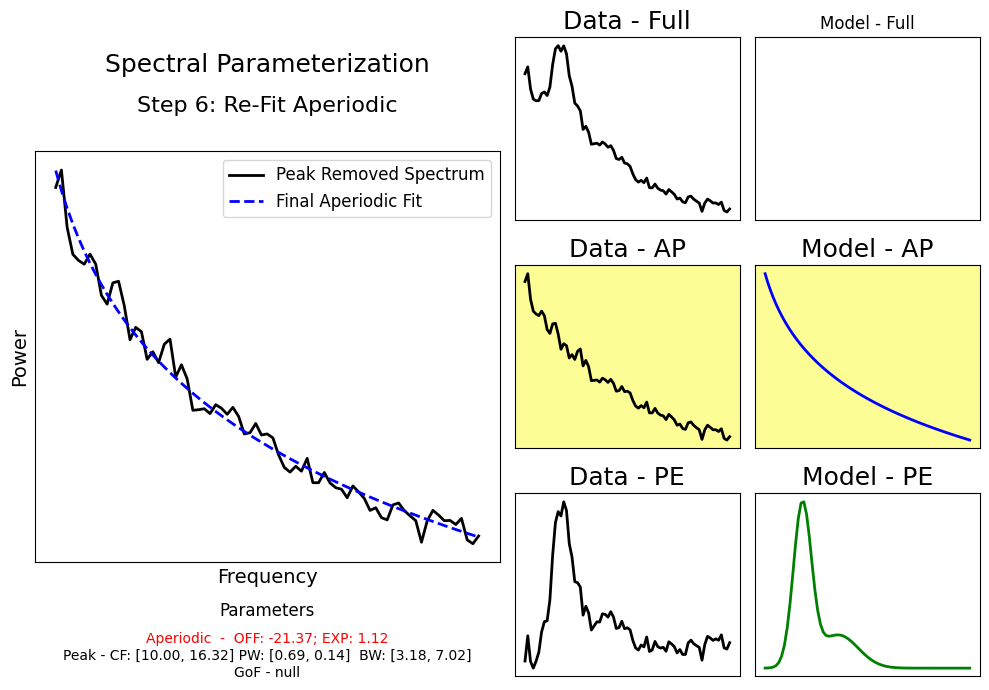

In [24]:
fig, axes = make_axes()

plot_spectra(fm.data.freqs, fm.get_data('aperiodic'), ax=axes['main'],
             color=PLT_COLORS['data'], label='Peak Removed Spectrum')
plot_spectra(fm.data.freqs, fm.results.model.get_component('aperiodic'), ax=axes['main'],
             color=PLT_COLORS['aperiodic'], linestyle='dashed', label='Final Aperiodic Fit')

plot_spectra(fm.data.freqs, fm.data.power_spectrum, ax=axes['data_fu'],
             color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, init_ap_fit, ax=axes['model_ap'],
             color=PLT_COLORS['aperiodic'], **labels)
plot_spectra(fm.data.freqs, init_flat_spec, ax=axes['data_pe'],
             color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, fm.results.model.get_component('peak'), ax=axes['model_pe'],
             color=PLT_COLORS['periodic'], **labels)
plot_spectra(fm.data.freqs, fm.get_data('aperiodic'), ax=axes['data_ap'],
             color=PLT_COLORS['data'], **labels)
axes['data_ap'].set_facecolor(face_color)
axes['model_ap'].set_facecolor(face_color)

axes['text_top'].text(0.5, 0.0, 'Step 6: Re-Fit Aperiodic', **TEXT_KWARGS, fontsize=16)
add_param_text(axes['text_bot'], ap=fm.results.get_params('aperiodic'),
               pe=fm.results.get_params('peak'), highlight='ap')

### Step 7 

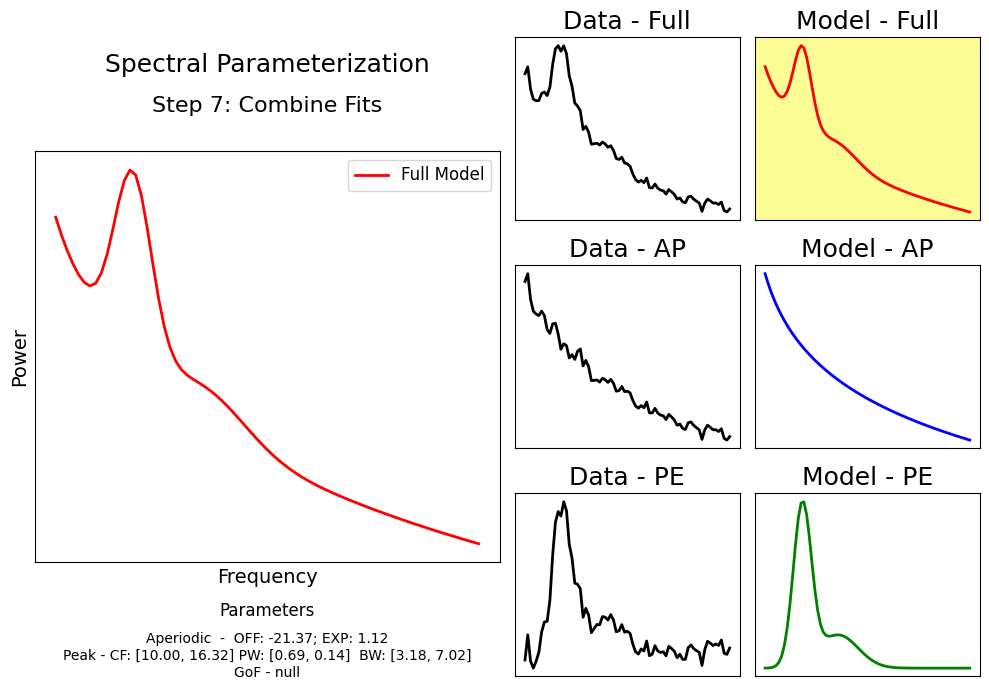

In [25]:
fig, axes = make_axes()

plot_spectra(fm.data.freqs, fm.results.model.get_component('full'),
             ax=axes['main'], color=PLT_COLORS['model'], label='Full Model')

plot_spectra(fm.data.freqs, fm.data.power_spectrum, ax=axes['data_fu'],
             color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, fm.results.model.get_component('aperiodic'), ax=axes['model_ap'],
             color=PLT_COLORS['aperiodic'], **labels)
plot_spectra(fm.data.freqs, fm.get_data('peak'), ax=axes['data_pe'],
             color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, fm.results.model.get_component('peak'), ax=axes['model_pe'],
             color=PLT_COLORS['periodic'], **labels)
plot_spectra(fm.data.freqs, fm.get_data('aperiodic'), ax=axes['data_ap'],
             color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, fm.results.model.get_component('full'), ax=axes['model_fu'],
             color=PLT_COLORS['model'], **labels)

axes['model_fu'].set_facecolor(face_color)

axes['text_top'].text(0.5, 0.0, 'Step 7: Combine Fits', **TEXT_KWARGS, fontsize=16)
add_param_text(axes['text_bot'],
               ap=fm.results.get_params('aperiodic'),
               pe=fm.results.get_params('peak'))

### Step 8

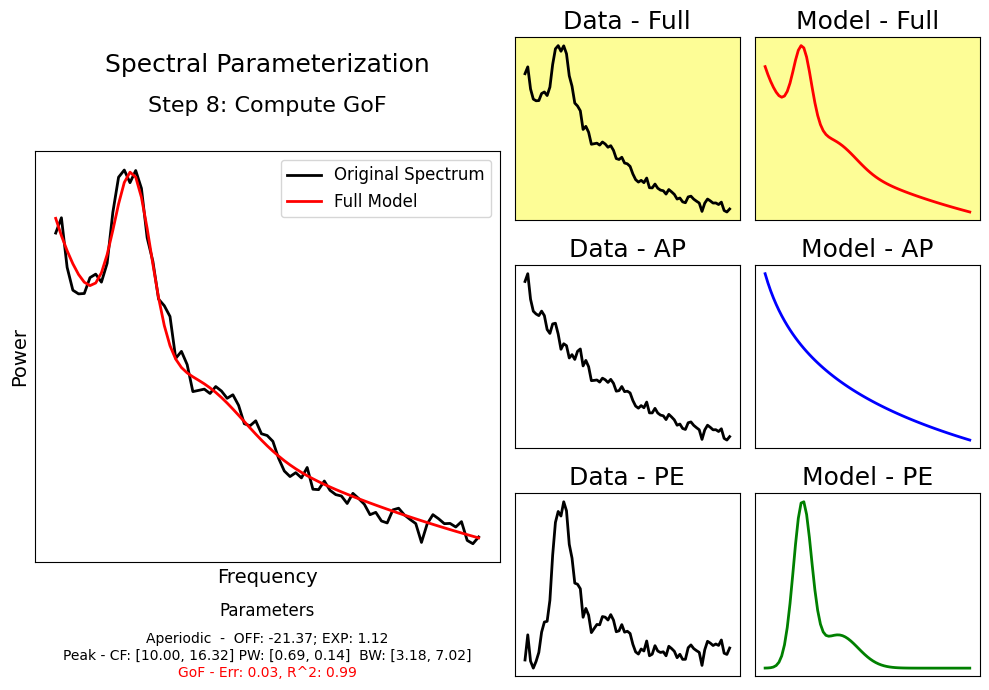

In [26]:
fig, axes = make_axes()

plot_spectra(fm.data.freqs, fm.data.power_spectrum, ax=axes['main'],
             color=PLT_COLORS['data'], label='Original Spectrum')
plot_spectra(fm.data.freqs, fm.results.model.get_component('full'),
             ax=axes['main'], color=PLT_COLORS['model'], label='Full Model')

plot_spectra(fm.data.freqs, fm.data.power_spectrum, ax=axes['data_fu'],
             color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, fm.results.model.get_component('aperiodic'), ax=axes['model_ap'],
             color=PLT_COLORS['aperiodic'], **labels)
plot_spectra(fm.data.freqs, fm.get_data('peak'), ax=axes['data_pe'], color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, fm.results.model.get_component('peak'), ax=axes['model_pe'],
             color=PLT_COLORS['periodic'], **labels)
plot_spectra(fm.data.freqs, fm.get_data('aperiodic'), ax=axes['data_ap'],
             color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, fm.results.model.get_component('full'), ax=axes['model_fu'],
             color=PLT_COLORS['model'], **labels)

axes['data_fu'].set_facecolor(face_color)
axes['model_fu'].set_facecolor(face_color)

axes['text_top'].text(0.5, 0.0, 'Step 8: Compute GoF', **TEXT_KWARGS, fontsize=16)
add_param_text(axes['text_bot'],
               ap=fm.results.get_params('aperiodic'),
               pe=fm.results.get_params('peak'),
               gof=fm.results.metrics.results,
               highlight='gof')

### Step 9

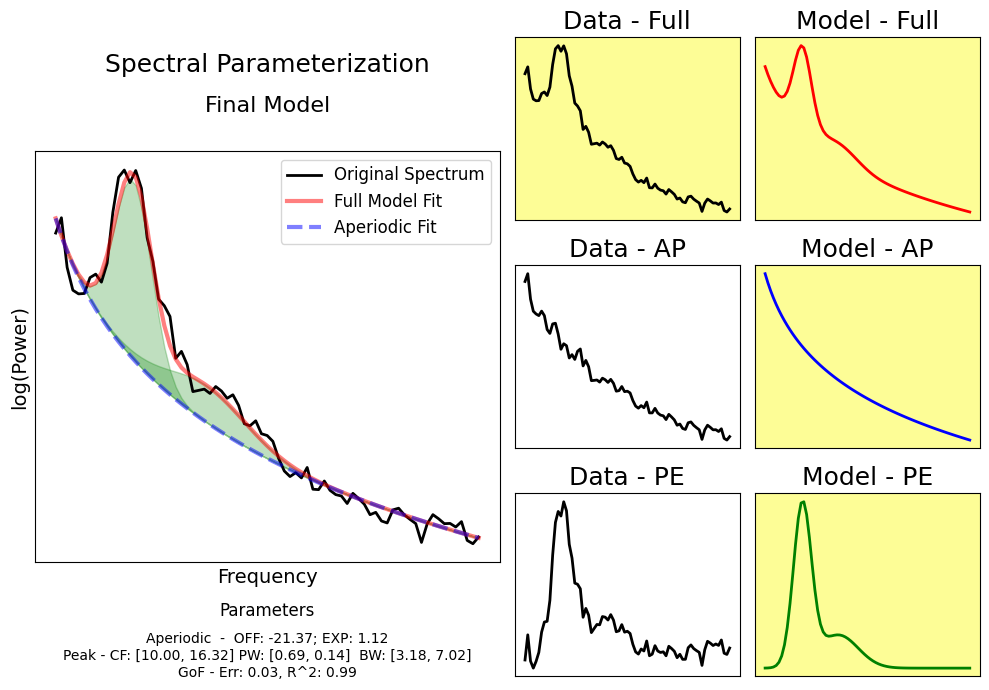

In [27]:
fig, axes = make_axes()

fm.plot(plot_peaks='shade', ax=axes['main'])

plot_spectra(fm.data.freqs, fm.data.power_spectrum, ax=axes['data_fu'],
             color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, fm.results.model.get_component('aperiodic'), ax=axes['model_ap'],
             color=PLT_COLORS['aperiodic'], **labels)
plot_spectra(fm.data.freqs, fm.get_data('peak'), ax=axes['data_pe'], color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, fm.results.model.get_component('peak'), ax=axes['model_pe'],
             color=PLT_COLORS['periodic'], **labels)
plot_spectra(fm.data.freqs, fm.get_data('aperiodic'), ax=axes['data_ap'],
             color=PLT_COLORS['data'], **labels)
plot_spectra(fm.data.freqs, fm.results.model.get_component('full'), ax=axes['model_fu'],
             color=PLT_COLORS['model'], **labels)

axes['data_fu'].set_facecolor(face_color)
axes['model_fu'].set_facecolor(face_color)
axes['model_ap'].set_facecolor(face_color)
axes['model_pe'].set_facecolor(face_color)

axes['text_top'].text(0.5, 0.0, 'Final Model', **TEXT_KWARGS, fontsize=16)
add_param_text(axes['text_bot'],
               ap=fm.results.get_params('aperiodic'),
               pe=fm.results.get_params('peak'),
               gof=fm.results.metrics.results)